# Лабораторная работа №7
Методы оптимизации в нейросетевых вычислениях\
Вариант 10

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

## Задание 1 (3 балла)
Исследуйте функцию нескольких переменных по варианту в заданной
области аналитически: определите седловые точки, локальные экстремумы, глобальный
минимум. Напишите программный модуль для построения линий уровня этой функции. Сделайте
выводы, какие сложности для оптимизационного алгоритма могут быть в случае такой функции

Заданная функция
$$
    f(x,y)= 10^{-2} \cdot (8x^2+2xy+11x+2y+3) \quad \quad

    x \in [-20; 20] \quad y \in [-50; 50]
$$

---
**1. Найдём стационарные точки**

Найдём частные производные:

$$
    f_x =  10^{-2} \cdot (16x + 2y + 11) \quad f_y =  10^{-2} \cdot (2x + 2)
$$
Решим систему:
$$
    \begin{cases}
    10^{-2} \cdot (16x + 2y + 11) = 0 \\
    10^{-2} \cdot (2x + 2) = 0
    \end{cases}
$$

Из второго уравнения:
$$
    x = -1
$$

Подставим в первое:
$$
    16(-1) + 2y + 11 = 0 \\
    -16 + 2y + 11 = 0 \\
    2y = 5 \Rightarrow y = 2.5
$$

*Стационарная точка:* $(-1,\; 2.5)$

---

**2. Исследование на тип точки**

Матрица Гессе:

$$
    H =
        \begin{pmatrix}
        16 & 2 \\
        2 & 0
        \end{pmatrix} \\

    \det H = -4 < 0
$$

*Точка $(-1, 2.5)$ - седловая*

---

**3. Экстремумы**

- Локальных минимумов нет  
- Локальных максимумов нет  
- Глобального минимума нет  

Функция не является знакоопределённой квадратичной формой, поэтому не ограничена снизу и сверху.

---

**4. Вывод о сложности оптимизации**

Данная функция создаёт трудности для градиентных методов:
- наличие седловой точки
- отсутствие минимума
- разные направления кривизны (неопределённый Гессиан)

Градиентный спуск может:
- застревать в окрестности седловой точки
- плохо сходиться без регуляризации или адаптивных методов

---

**5. Граница области**

1. Ребро $y=50$

$$
f(x,50)=10^{-2}(8x^2+111x+103)
$$

$$
f'(x)=10^{-2}(16x+111)=0 \Rightarrow x=-\frac{111}{16}
$$

$$
f\left(-\frac{111}{16},50\right)\approx -2.8203
$$

2. Ребро $y=-50$

$$
f(x,-50)=10^{-2}(8x^2-89x-97)
$$

$$
f'(x)=10^{-2}(16x-89)=0 \Rightarrow x=\frac{89}{16}
$$

$$
f\left(\frac{89}{16},-50\right)\approx -3.4453
$$

3. Ребро $x=20$

$$
f(20,y)=10^{-2}(3423+42y)
\Rightarrow y=-50
$$

$$
f(20,-50)=13.23
$$

4. Ребро $x=-20$

$$
f(-20,y)=10^{-2}(2983-38y)
\Rightarrow y=50
$$

$$
f(-20,50)=10.83
$$

5. Сравнение значений

$$
\begin{aligned}
f(-1,2.5) &= 0 \\
f(-20,50) &= 10.83 \\
f(20,-50) &= 13.23 \\
f\left(-\frac{111}{16},50\right) &\approx -2.8203 \\
f\left(\frac{89}{16},-50\right) &\approx -3.4453
\end{aligned}
$$

6. Глобальный минимум

$$
f_{\min} \approx -3.4453
\quad \text{в точке} \quad
\left(\frac{89}{16},-50\right)
$$

---

**6. Собственные значения**

$$
\det(H - \lambda I)=0
$$

$$
\begin{vmatrix}
16-\lambda & 2 \\
2 & -\lambda
\end{vmatrix}
= (16-\lambda)(-\lambda) - 4 = 0
$$

$$
\lambda^2 - 16\lambda - 4 = 0
$$

$$
\lambda_{1,2} = 8 \pm 2\sqrt{17}
$$

1. Для $\lambda_1 = 8 + 2\sqrt{17}$

$$
(H - \lambda_1 I)v = 0
$$

$$
v_1 \sim
\begin{pmatrix}
2 \\
\lambda_1 - 16
\end{pmatrix}
$$

2.  Для $\lambda_2 = 8 - 2\sqrt{17}$

$$
(H - \lambda_2 I)v = 0
$$

$$
v_2 \sim
\begin{pmatrix}
2 \\
\lambda_2 - 16
\end{pmatrix}
$$

3. Наайдём точку старта

$$
    v_1 \sim (2,\lambda_1 - 16) \approx (2,0.246) \\
    (x_0​, y_0​) = (-1,2.5) + t \cdot (2, 0.246) \quad (x_0, y_0) = (9, 3.73)
$$

In [2]:
F = lambda x, y: 10**(-2) * (8*x**2 + 2*x*y + 11*x + 2*y + 3)

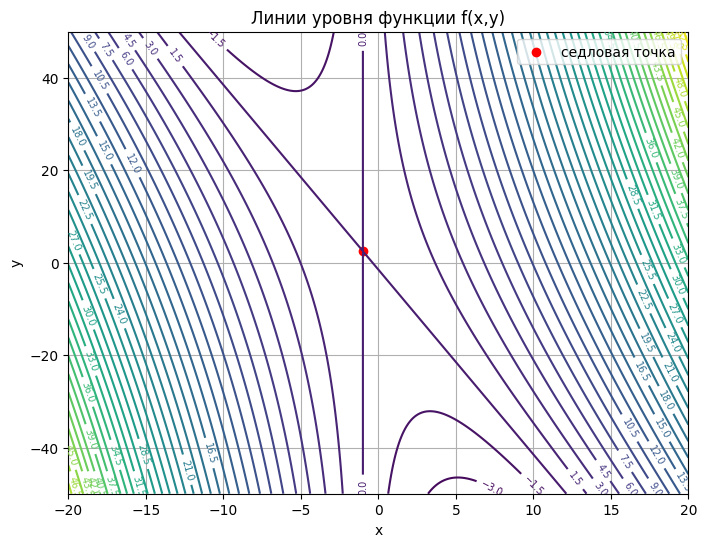

In [3]:
# сетка
x = np.linspace(-20, 20, 500)
y = np.linspace(-50, 50, 500)
X, Y = np.meshgrid(x, y)

Z = F(X, Y)

# график
plt.figure(figsize=(8, 6))

contours = plt.contour(X, Y, Z, levels=40)
plt.clabel(contours, inline=True, fontsize=7)

# седловая точка
plt.scatter(-1, 2.5, color='red', label='седловая точка')

plt.title("Линии уровня функции f(x,y)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc="upper right")
plt.grid(True)

plt.show()

## Задание 2 (5 баллов, по 1 баллу за каждый пункт, в п.3 – 2 балла).
1. Выберите начальное приближение, скорость обучения, критерий останова так, чтобы
последовательные приближения градиентного спуска сходились к седловой точке за ~100
итераций (помимо критериев из предыдущих разделов – норма градиента близка к нулю с
заданной точностью, значения функции близки с заданной точностью – здесь важно
зафиксировать количество итераций, так как оно будет использоваться далее). Сделайте
визуализацию линий уровня и последовательных приближений. Начальное приближение,
седловую точку, количество итераций из этого пункта используйте во всех последующих.
2. Реализуйте программно эвристики для градиентного спуска (метод по варианту). С помощью
реализованных эвристик получите за то же количество итераций последовательность
приближений, которая «преодолевает» седловую точку.
3. Подберите область отображения для эффективной иллюстрации диаграммы последовательных
приближений. Не меняя область отображения, найдите значения гиперпараметров:
(1) в области явно просматривается движение в стороны от направления к глобальному
минимуму (пилообразная ломаная),
(2) в области направление более чёткое без движений в стороны.
4. Используйте готовую реализацию одной из эвристик для градиентного спуска (рекомендуются
функции PyTorch: https://docs.pytorch.org/docs/stable/optim.html). Убедитесь, что алгоритм
успешно решает задачу «преодоления» седловой точки и постройте один вариант визуализации
диаграммы последовательных приближений (в области из п.3)

In [4]:
# Гиперпараметры
lr = 2
beta = 0.91
n_iter = 100

# Старт
x0 = np.array([9.0, 4])

# Седловая точка
saddle = np.array([-1.0, 2.5])

### Градиентный спуск

Обновление параметров задаётся формулой:

$$
x_{k+1} = x_k - \eta \nabla f(x_k)
$$

где:
- $x_k$ — текущая точка
- $\eta$ — скорость обучения (learning rate)
- $\nabla f(x_k)$ — градиент функции в точке $x_k$

In [5]:
def grad(x, y):
    df_dx =  10**(-2) * (16*x + 2*y + 11)
    df_dy =  10**(-2) * (2*x + 2)
    return np.array([df_dx, df_dy])

path = [x0.copy()]

x = x0.copy()

for i in range(n_iter):
    g = grad(x[0], x[1])
    x = x - lr * g
    path.append(x.copy())

path = np.array(path)

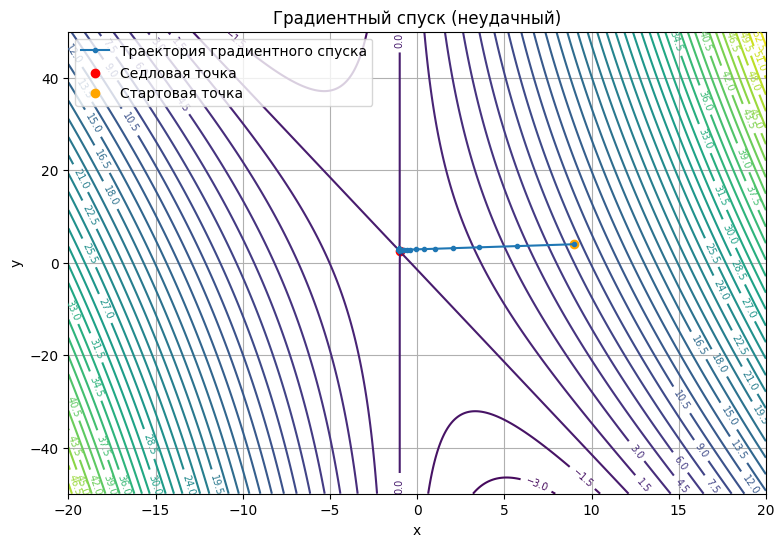

In [6]:
# сетка
x_grid = np.linspace(-20, 20, 400)
y_grid = np.linspace(-50, 50, 400)
X, Y = np.meshgrid(x_grid, y_grid)

Z = F(X, Y)

plt.figure(figsize=(9, 6))

# линии уровня
contours = plt.contour(X, Y, Z, levels=40)
plt.clabel(contours, fontsize=7)

# траектория
plt.plot(path[:,0], path[:,1], 'o-', label="Траектория градиентного спуска", markersize=3)

# седло
plt.scatter(-1, 2.5, color='red', label="Cедловая точка")

# старт
plt.scatter(x0[0], x0[1], color='orange', label="Стартовая точка")

plt.title("Градиентный спуск (неудачный)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc = "upper left")
plt.grid()
plt.show()

In [7]:
path[-1]

array([-1.05330139,  2.93297284])

### Градиентный спуск с Momentum


Модификация градиентного спуска с инерцией:

$$
v_{k+1} = \beta v_k - \eta \nabla f(x_k)
$$

$$
x_{k+1} = x_k + v_{k+1}
$$

где:
- $v_k$ — “скорость” (накопленный импульс)
- $\beta \in [0,1)$ — коэффициент инерции
- $\eta$ — learning rate

#### Пилообразный

In [7]:
x = x0.copy()
v = np.zeros(2)

path_m = [x.copy()]

for i in range(n_iter):
    g = grad(x[0], x[1])
    v = beta * v - lr * g
    x = x + v
    path_m.append(x.copy())

path_m = np.array(path_m)

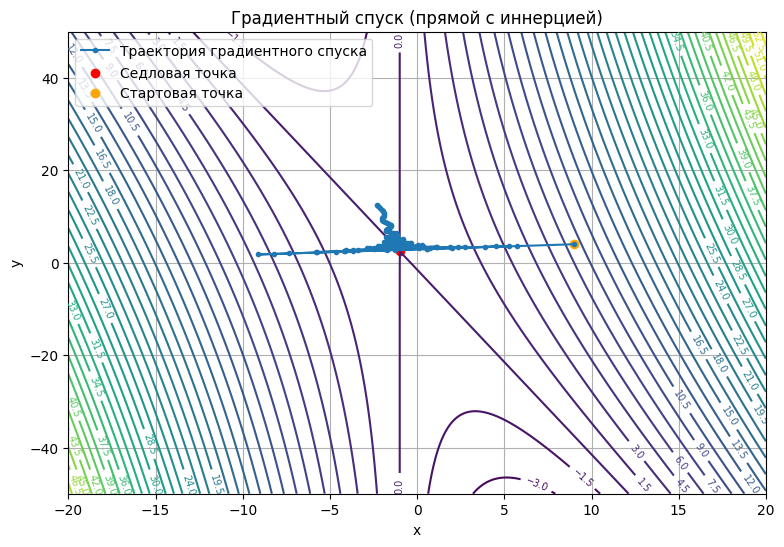

In [8]:
x_grid = np.linspace(-20, 20, 400)
y_grid = np.linspace(-50, 50, 400)
X, Y = np.meshgrid(x_grid, y_grid)

Z = F(X, Y)

plt.figure(figsize=(9, 6))

# линии уровня
contours = plt.contour(X, Y, Z, levels=40)
plt.clabel(contours, fontsize=7)

# траектория
plt.plot(path_m[:,0], path_m[:,1], 'o-', label="Траектория градиентного спуска", markersize=3)

# седло
plt.scatter(-1, 2.5, color='red', label="Cедловая точка")

# старт
plt.scatter(x0[0], x0[1], color='orange', label="Стартовая точка")

plt.title("Градиентный спуск (прямой с иннерцией)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc = "upper left")
plt.grid()
plt.show()

#### Более прямой

In [9]:
lr_local = 9
beta_local = 0.50

x = x0.copy()
v = np.zeros(2)

path_m2 = [x.copy()]

for i in range(n_iter):
    g = grad(x[0], x[1])
    v = beta_local * v - lr_local * g
    x = x + v
    path_m2.append(x.copy())

path_m2 = np.array(path_m2)

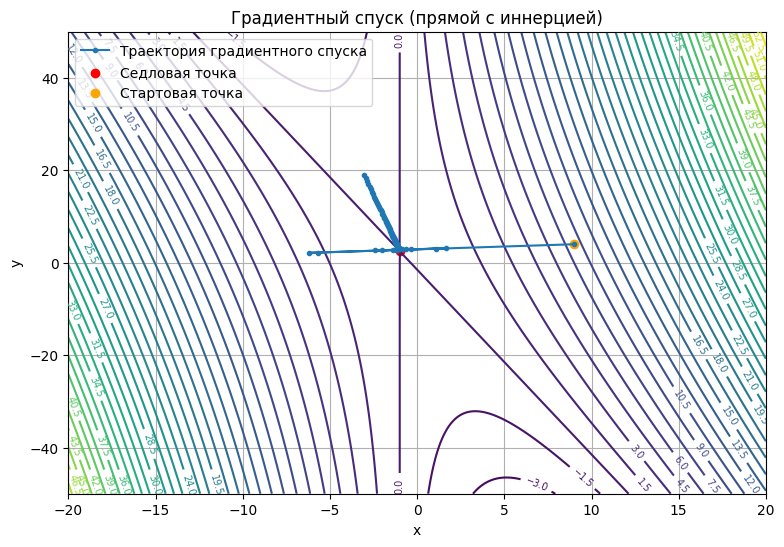

In [10]:
x_grid = np.linspace(-20, 20, 400)
y_grid = np.linspace(-50, 50, 400)
X, Y = np.meshgrid(x_grid, y_grid)

Z = F(X, Y)

plt.figure(figsize=(9, 6))

# линии уровня
contours = plt.contour(X, Y, Z, levels=40)
plt.clabel(contours, fontsize=7)

# траектория
plt.plot(path_m2[:,0], path_m2[:,1], 'o-', label="Траектория градиентного спуска", markersize=3)

# седло
plt.scatter(-1, 2.5, color='red', label="Cедловая точка")

# старт
plt.scatter(x0[0], x0[1], color='orange', label="Стартовая точка")

plt.title("Градиентный спуск (прямой с иннерцией)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc = "upper left")
plt.grid()
plt.show()

### Оптимизация при помощи PyTorch

In [11]:
x = torch.tensor(x0, requires_grad=True)

# оптимизатор
# SGD
optimizer = torch.optim.SGD([x], lr=lr, momentum=beta)

n_iter = 100

path_torch = []

for i in range(n_iter):
    optimizer.zero_grad()

    # вычисление градиента
    F(x[0], x[1]).backward()

    # шаг оптимизации
    optimizer.step()

    path_torch.append(x.detach().numpy().copy())

path_torch = np.array(path_torch)

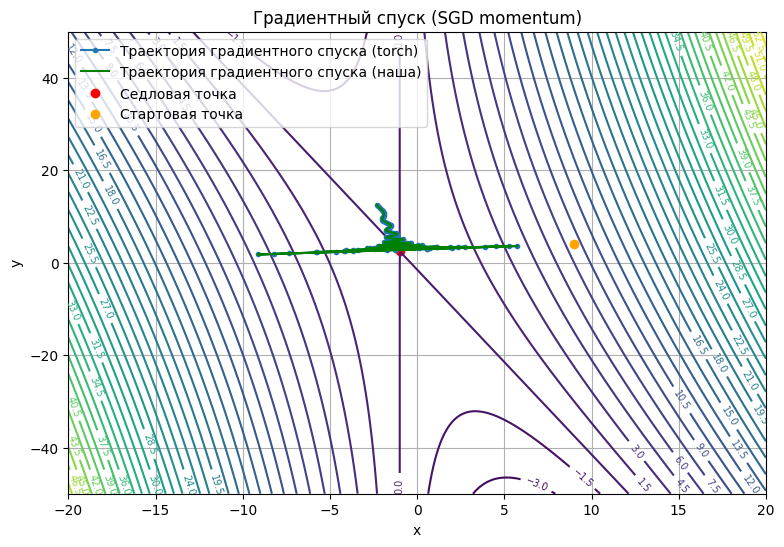

In [12]:
x_grid = np.linspace(
    min(-20, min(i[0] for i in path_torch)),
    max(20, max(i[0] for i in path_torch)),
    400
)
y_grid = np.linspace(
    min(-50, min(i[1] for i in path_torch)),
    max(50, max(i[1] for i in path_torch)),
    400
)
X, Y = np.meshgrid(x_grid, y_grid)

Z = F(X, Y)

plt.figure(figsize=(9, 6))

# линии уровня
contours = plt.contour(X, Y, Z, levels=40)
plt.clabel(contours, fontsize=7)

# траектория
plt.plot(path_torch[:,0], path_torch[:,1], 'o-', label="Траектория градиентного спуска (torch)", markersize=3)
plt.plot(path_torch[:,0], path_torch[:,1], 'g-', label="Траектория градиентного спуска (наша)", markersize=3)


# седло
plt.scatter(-1, 2.5, color='red', label="Cедловая точка")

# старт
plt.scatter(x0[0], x0[1], color='orange', label="Стартовая точка")

plt.title("Градиентный спуск (SGD momentum)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc = "upper left")
plt.grid()
plt.show()

## Задание 3

Обучение нейронной сети на датасете \
Используется датасет с хакатона "Дикая жизнь Уташуда"

In [13]:
import os
from glob import glob
from dataclasses import dataclass

import numpy as np
from PIL import Image

from tqdm import tqdm

import torch
from torch import nn
from torch.optim.optimizer import Optimizer
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [15]:
@dataclass
class Config:
    train_path = "train/"
    test_path = "test/"
    
    image_size = (128, 512)
    
    batch_size = 8
    num_epochs = 20
    
    learning_rate = 1e-2
    weight_decay = 1e-4
    
    random_state = 42

config = Config()

In [16]:
X_train, X_val = train_test_split(
    glob(f"{config.train_path}*/*"),
    test_size=0.3,
    random_state=config.random_state
)

print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")

Train size: 953
Validation size: 409


In [17]:
class Tools:
    @staticmethod
    def crop_seals(path, version="v2"):
        im = Image.open(path).convert("RGB")

        if version == "v1":
            im = im.crop((100, 0, 3500, 700))

        elif version == "v2":
            img = Image.new("RGB", (3400, 200))

            h_array = (
                [500, 470, 430, 380, 320,
                 260, 230, 200, 170,
                 150, 120]
                + [90 for _ in range(4)]
                + [70 for _ in range(2)]
            )

            for pixel_w, pixel_h in zip(range(0, 3401, 200), h_array):
                cached_img = im.crop(
                    (pixel_w, pixel_h, pixel_w + 200, pixel_h + 200)
                )

                img.paste(cached_img, (pixel_w, 0))

            im = img

        else:
            raise Exception(f"Unknown version: {version}")

        return im

In [18]:
def save_crops(
    image_paths,
    save_dir="cropped_train",
    version="v2"
):
    os.makedirs(save_dir, exist_ok=True)

    for path in tqdm(image_paths):

        class_name = path.split("/")[-2]
        class_dir = os.path.join(save_dir, class_name)
        os.makedirs(class_dir, exist_ok=True)

        file_name = path.split("/")[-1]

        image = Tools.crop_seals(path, version=version)

        save_path = os.path.join(class_dir, file_name)

        image.save(save_path)

In [19]:
# save_crops(
#     X_train,
#     save_dir="cropped_train",
#     version="v2"
# )
# save_crops(
#     X_val,
#     save_dir="cropped_val",
#     version="v2"
# )

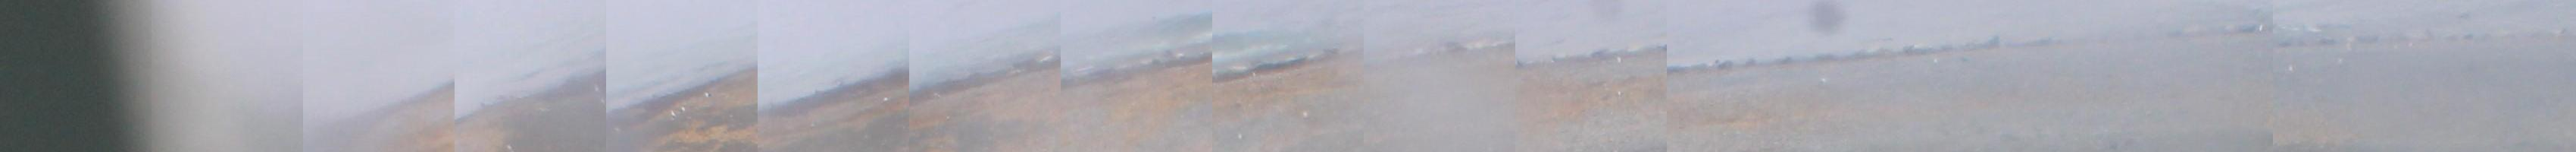

In [20]:
sample_path = glob("cropped_train/*/*")[0]

Image.open(sample_path)

In [21]:
X_train_crop = glob("cropped_train/*/*")
X_val_crop = glob("cropped_val/*/*")

In [22]:
transform_train = transforms.Compose([
    transforms.Resize(config.image_size, antialias=True),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(3),

    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

transform_val = transforms.Compose([
    transforms.Resize(config.image_size, antialias=True),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [23]:
class FastSealDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

    def __getitem__(self, idx):
        path = self.image_paths[idx]

        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = int(path.split("/")[-2] == "seal")

        return image, torch.tensor(label, dtype=torch.float32)

    def __len__(self):
        return len(self.image_paths)

In [24]:
train_loader = DataLoader(
    FastSealDataset(X_train_crop, transform_train),
    batch_size=config.batch_size,
    shuffle=True,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4
)

val_loader = DataLoader(
    FastSealDataset(X_val_crop, transform_val),
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4
)

In [25]:
class SealCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(512, 128),
            nn.LeakyReLU(),

            nn.Dropout(0.3),

            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)

        return x


In [26]:
class SGDWithMomentum(Optimizer):
    def __init__(self, params, lr=1e-3, momentum=0.9, weight_decay=0.0):
        defaults = dict(lr=lr, momentum=momentum, weight_decay=weight_decay)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            loss = closure()

        for group in self.param_groups:
            lr = group["lr"]
            momentum = group["momentum"]
            weight_decay = group["weight_decay"]

            for p in group["params"]:
                if p.grad is None:
                    continue

                grad = p.grad

                # weight decay (L2)
                if weight_decay != 0:
                    grad = grad.add(p, alpha=weight_decay)

                state = self.state[p]

                # init momentum buffer
                if "velocity" not in state:
                    state["velocity"] = torch.zeros_like(p)

                v = state["velocity"]

                # v = m*v + g
                v.mul_(momentum).add_(grad)

                # p = p - lr * v
                p.add_(v, alpha=-lr)

        return loss

### BCE

Пусть:
- $x$ — логит (выход модели до сигмоиды)
- $y \in \{0,1\}$ — истинная метка

Тогда бинарная кросс-энтропия:

$$
\mathrm{BCEWithLogitsLoss}(x,y)
=
- \Big(
y \cdot \log(\sigma(x)) + (1-y)\cdot \log(1-\sigma(x))
\Big)
$$

где сигмоида:

$$
\sigma(x)=\frac{1}{1+e^{-x}}
$$

### Усреднение по батчу

$$
\mathcal{L}
=
\frac{1}{N}\sum_{i=1}^N \mathrm{BCEWithLogitsLoss}(x_i, y_i)
$$

In [27]:
def get_model():
    return SealCNN().to(device)

model_custom = get_model()
model_torch = get_model()

#optimizer = torch.optim.SGD(
#    model.parameters(),
#    lr=config.learning_rate,
#    weight_decay=config.weight_decay
#)

optimizer_custom = SGDWithMomentum(
    model_custom.parameters(),
    lr=config.learning_rate,
    weight_decay=config.weight_decay
)

optimizer_torch = torch.optim.SGD(
    model_torch.parameters(),
    lr=config.learning_rate,
    momentum=beta,
    weight_decay=config.weight_decay
)

criterion = nn.BCEWithLogitsLoss()

scheduler_custom = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_custom,
    mode='min',
    factor=0.25,
    patience=2,
    threshold=0.001,
    threshold_mode='rel',
    cooldown=1,
    min_lr=1e-5
)

scheduler_torch = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_torch,
    mode='min',
    factor=0.25,
    patience=2,
    threshold=0.001,
    threshold_mode='rel',
    cooldown=1,
    min_lr=1e-5
)

In [28]:
def train_loop(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0

    progress_bar = tqdm(loader)

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images).squeeze(1)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        progress_bar.set_postfix({
            "loss": loss.item()
        })

    return total_loss / len(loader)

@torch.no_grad()
def val_loop(model, loader, criterion, device):
    model.eval()

    total_loss = 0

    y_true = []
    y_pred = []

    progress_bar = tqdm(loader)

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images).squeeze(1)

        loss = criterion(outputs, labels)

        total_loss += loss.item()

        probs = torch.sigmoid(outputs)

        preds = (probs > 0.5).int()

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

        progress_bar.set_postfix({
            "loss": loss.item()
        })

    avg_loss = total_loss / len(loader)

    # F1
    f1 = f1_score(y_true, y_pred)

    # Accuracy (доля верных предсказаний)
    accuracy = np.mean(np.array(y_true) == np.array(y_pred))

    return avg_loss, f1, accuracy

In [29]:
history = {
    "custom_train_loss": [],
    "torch_train_loss": [],
    "custom_val_loss": [],
    "torch_val_loss": []
}


def train_model(
    model_custom,
    model_torch,
    train_loader,
    val_loader,
    optimizer_custom,
    optimizer_torch,
    criterion,
    scheduler_custom,
    scheduler_torch,
    device,
    epochs=10
):
    os.makedirs("checkpoints", exist_ok=True)

    for epoch in range(epochs):

        print(f"\n===== Epoch {epoch + 1} =====")

        # CUSTOM MODEL
        model_custom.train()
        train_loss_custom = train_loop(
            model_custom,
            train_loader,
            optimizer_custom,
            criterion,
            device
        )

        val_loss_custom, _, val_acc_custom = val_loop(
            model_custom,
            val_loader,
            criterion,
            device
        )

        scheduler_custom.step(val_loss_custom)

        # TORCH MODEL
        model_torch.train()
        train_loss_torch = train_loop(
            model_torch,
            train_loader,
            optimizer_torch,
            criterion,
            device
        )

        val_loss_torch, _, val_acc_torch = val_loop(
            model_torch,
            val_loader,
            criterion,
            device
        )

        scheduler_torch.step(val_loss_torch)

        history["custom_train_loss"].append(train_loss_custom)
        history["custom_val_loss"].append(val_loss_custom)

        history["torch_train_loss"].append(train_loss_torch)
        history["torch_val_loss"].append(val_loss_torch)

        print(f"Custom train loss: {train_loss_custom:.4f} | val: {val_loss_custom:.4f} & custom acc: {val_acc_custom:.4f}")
        print(f"Torch  train loss: {train_loss_torch:.4f} | val: {val_loss_torch:.4f} & torch acc: {val_acc_torch:.4f}")
train_model(
    model_custom,
    model_torch,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer_custom=optimizer_custom,
    optimizer_torch=optimizer_torch,
    criterion=criterion,
    scheduler_custom=scheduler_custom,
    scheduler_torch=scheduler_torch,
    device=device,
    epochs=config.num_epochs
)


===== Epoch 1 =====


100%|██████████| 52/52 [00:01<00:00, 41.38it/s, loss=0.631]


Custom train loss: 0.6723 | val: 0.6486 & custom acc: 0.5966
Torch  train loss: 0.6811 | val: 0.6556 & torch acc: 0.5966

===== Epoch 2 =====


100%|██████████| 52/52 [00:01<00:00, 41.19it/s, loss=0.698]


Custom train loss: 0.6660 | val: 0.6808 & custom acc: 0.6088
Torch  train loss: 0.6686 | val: 0.6593 & torch acc: 0.5892

===== Epoch 3 =====


...

Custom train loss: 0.6048 | val: 0.5938 & custom acc: 0.7066
Torch  train loss: 0.6070 | val: 0.6177 & torch acc: 0.6797

===== Epoch 19 =====


100%|██████████| 52/52 [00:01<00:00, 40.63it/s, loss=0.784]


Custom train loss: 0.5988 | val: 0.5774 & custom acc: 0.7311
Torch  train loss: 0.6080 | val: 0.6194 & torch acc: 0.6773

===== Epoch 20 =====


100%|██████████| 52/52 [00:01<00:00, 40.65it/s, loss=0.573]

Custom train loss: 0.5765 | val: 0.6302 & custom acc: 0.6406
Torch  train loss: 0.6058 | val: 0.6099 & torch acc: 0.6895


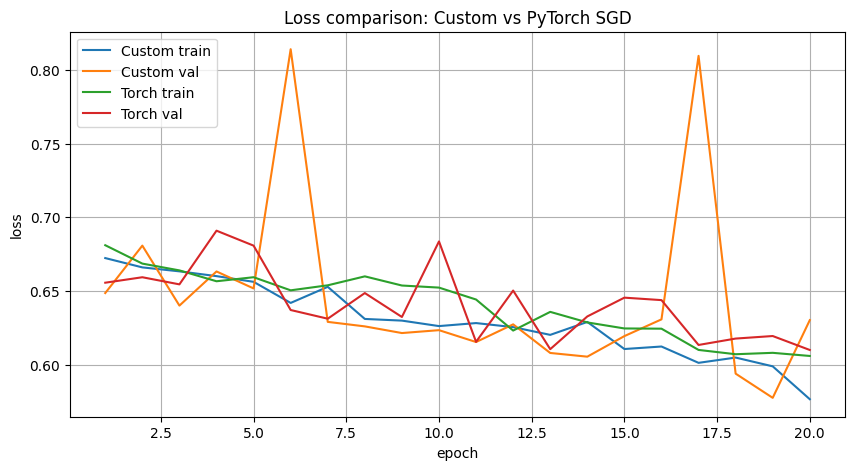

In [31]:
epochs_range = range(1, len(history["custom_train_loss"]) + 1)

plt.figure(figsize=(10, 5))

plt.plot(epochs_range, history["custom_train_loss"], label="Custom train")
plt.plot(epochs_range, history["custom_val_loss"], label="Custom val")

plt.plot(epochs_range, history["torch_train_loss"], label="Torch train")
plt.plot(epochs_range, history["torch_val_loss"], label="Torch val")

plt.title("Loss comparison: Custom vs PyTorch SGD")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid()

plt.show()